Para poder hallar el tiempo $\Delta t$ 

Ejecutando simulación en lazo cerrado (Kp = 696)...


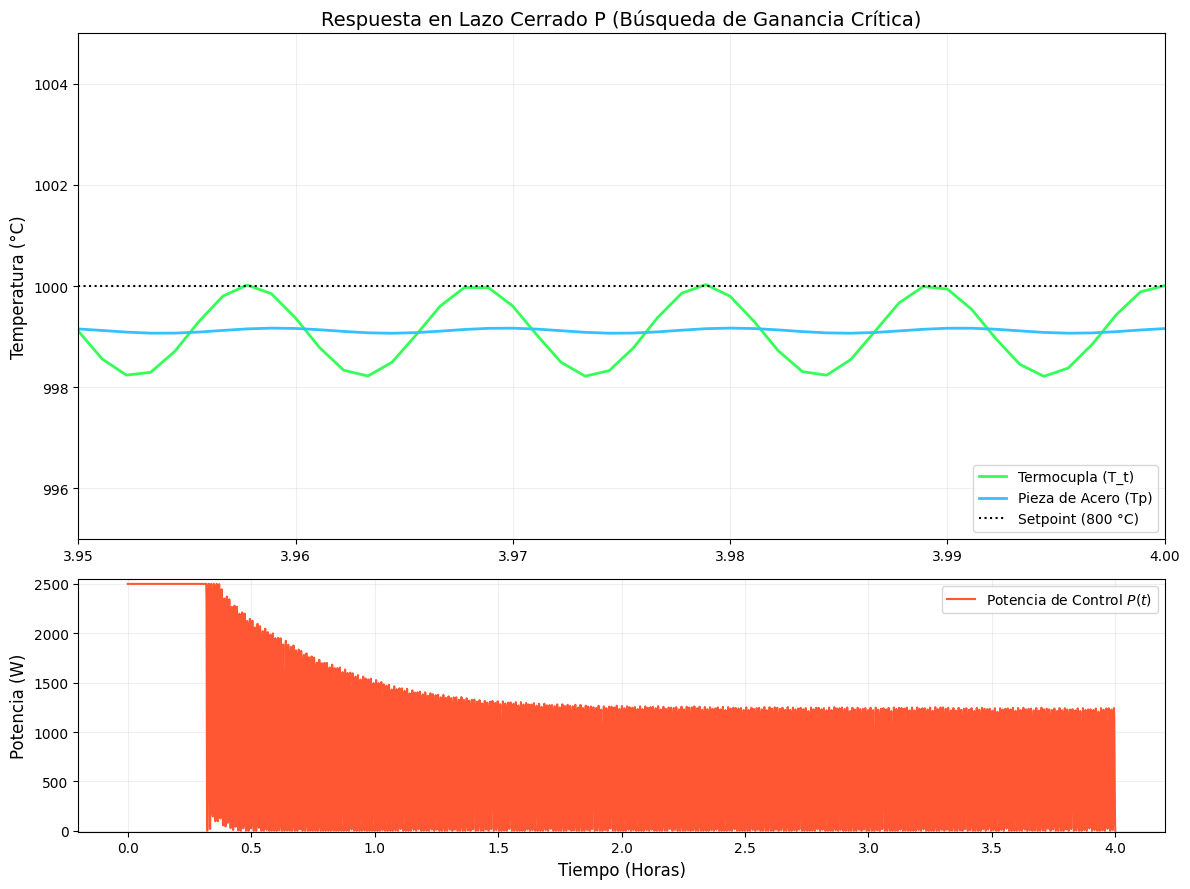

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. Propiedades Dependientes de T
# ==========================================
def c_r(T_C): return -0.0002 * (T_C**2) + 0.4804 * T_C + 467.6354
def k_lra(T_C): return -1e-8 * (T_C**2) + 0.0002 * T_C + 0.0990
def k_fc(T_C): return 9e-7 * (T_C**2) + 0.0009 * T_C + 0.3033
def k_lr(T_C): return 2e-7 * (T_C**2) + 0.0001 * T_C + 0.0301

# ==========================================
# 2. Modelo No Lineal con Controlador Proporcional Embebido
# ==========================================
def horno_lazo_cerrado_ode(t, y, Kp, T_sp_K, P_max, T_amb, m_p):
    if m_p != 0:
        Tr, Tp, Tt, T1, T2, T3, T4, T5 = y
    else:
        Tr, Tt, T1, T2, T3, T4, T5 = y
    
    # 2.1 Ley de Control Proporcional con Saturación
    error = T_sp_K - Tt
    P_req = Kp * error
    
    # Saturación física: La potencia no puede ser negativa ni mayor al nominal
    P_val = np.clip(P_req, 0, P_max)
    
    # 2.2 Conversiones y Evaluaciones Térmicas
    Tr_C = Tr - 273.15
    T12_C = ((T1 + T2) / 2.0) - 273.15
    T23_C = ((T2 + T3) / 2.0) - 273.15
    T34_C = ((T3 + T4) / 2.0) - 273.15
    T45_C = ((T4 + T5) / 2.0) - 273.15
    
    cr_val = c_r(Tr_C)
    klra_val_12 = k_lra(T12_C)
    kfc_val_23  = k_fc(T23_C)
    klr_val_34  = k_lr(T34_C)
    klr_val_45  = k_lr(T45_C)
    
    # 2.3 Ecuaciones Diferenciales
    dTr_dt = (3.44 / cr_val) * P_val - (1.24e-8 / cr_val) * (Tr**4 - T1**4)
    if m_p != 0.0:
        dTp_dt = (7.99e-13 + 6.57e-13 * np.sqrt(1/m_p)) * (T1**4 - Tp**4)
    dTt_dt = 2.0679e-11 * (T1**4 - Tt**4)
    if m_p != 0:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4) - 7.80e-14 * (T1**4 - Tp**4)
    else:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4)
    dT2_dt = 0.0026 * klra_val_12 * (T1 - T2) - 0.0051 * kfc_val_23 * (T2 - T3)
    dT3_dt = 0.0113 * kfc_val_23 * (T2 - T3) - 0.0161 * klr_val_34 * (T3 - T4)
    dT4_dt = 0.0253 * klr_val_34 * (T3 - T4) - 0.0342 * klr_val_45 * (T4 - T5)
    dT5_dt = 0.0595 * klr_val_45 * (T4 - T5) - 0.0202 * (T5 - T_amb) - 1.98e-11 * (T5**4 - T_amb**4)
    
    if m_p != 0.0:
        return [dTr_dt, dTp_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]
    else:
        return [dTr_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]

# ==========================================
# 3. Configuración de la Simulación
# ==========================================
T_amb_C = 15.0
T_amb = T_amb_C + 273.15
P_max = 2500.0             # Potencia máxima de tu equipo (W)
T_setpoint_C = 1000.0      # Temperatura objetivo (°C)
T_setpoint_K = T_setpoint_C + 273.15
m_p = 1000

# Parámetro crítico: Ganancia Proporcional (Ajustar hasta ver oscilación sostenida)
Kp_critico = 696   # 410-420

if m_p != 0.0:
    y0 = [T_amb] * 8
else:
    y0 = [T_amb] * 7
t_span = (0, 4 * 3600)  # 4 horas para asegurar que entra en régimen oscilatorio
t_eval = np.linspace(t_span[0], t_span[1], 3600)

print(f"Ejecutando simulación en lazo cerrado (Kp = {Kp_critico})...")
sol = solve_ivp(
    fun=lambda t, y: horno_lazo_cerrado_ode(t, y, Kp_critico, T_setpoint_K, P_max, T_amb, m_p),
    t_span=t_span,
    y0=y0,
    method='Radau',
    t_eval=t_eval,
    rtol=1e-4, 
    atol=1e-7
)

# ==========================================
# 4. Reconstrucción de la Señal de Control y Gráficas
# ==========================================
t_horas = sol.t / 3600
Tt_C = sol.y[2] - 273.15
Tp_C = sol.y[1] - 273.15

# Recalculamos P(t) para graficar qué está haciendo el controlador
errores = T_setpoint_C - Tt_C
P_aplicada = np.clip(Kp_critico * errores, 0, P_max)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [2, 1]})
plt.rcdefaults()
#plt.style.use('dark_background')

# Gráfica 1: Temperaturas (Identificación de Pu)
ax1.plot(t_horas, Tt_C, label='Termocupla (T_t)', color='#33FF57', linewidth=2)
if m_p != 0:
    ax1.plot(t_horas, Tp_C, label='Pieza de Acero (Tp)', color='#33C1FF', linewidth=2)
ax1.axhline(T_setpoint_C, color='black', linestyle=':', linewidth=1.5, label='Setpoint (800 °C)')
ax1.set_title(f'Respuesta en Lazo Cerrado P (Búsqueda de Ganancia Crítica)', fontsize=14)
ax1.set_ylabel('Temperatura (°C)', fontsize=12)
ax1.set_ylim(995, 1005)
ax1.set_xlim(3.95, 4.0)
ax1.grid(True, alpha=0.2)
ax1.legend(loc='lower right')

# Gráfica 2: Señal de Control (Comportamiento del SSR)
ax2.plot(t_horas, P_aplicada, label='Potencia de Control $P(t)$', color='#FF5733', linewidth=1.5)
ax2.set_xlabel('Tiempo (Horas)', fontsize=12)
ax2.set_ylabel('Potencia (W)', fontsize=12)
ax2.set_ylim(-10, P_max + 50)
ax2.grid(True, alpha=0.2)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Por lo que podemos hallat una ganancia proporcional límite de $P_u=0.011\text{ h}=39.6\text{ s}$, con $K_c=696$

Y con estos datos podemos hallar las constantes para un controlador PID.
$$K_P=0.6\cdot K_c=0.6\cdot 696=417.6$$
$$\tau_I=0.5\cdot P_u=0.5\cdot 39.6=19.8$$
$$\tau_D=0.125\cdot P_u=0.125\cdot =4.95$$

El siguiente programa realzia una simulación del comportamiento junto a un controlador PID con una entrada paso  de $1000\text{ °C}$.

Iniciando integración digital-continua. Este proceso puede tardar unos segundos...
--> 1 horas de operación simuladas...
--> 2 horas de operación simuladas...
--> 3 horas de operación simuladas...
Simulación completada en 15.07 segundos.


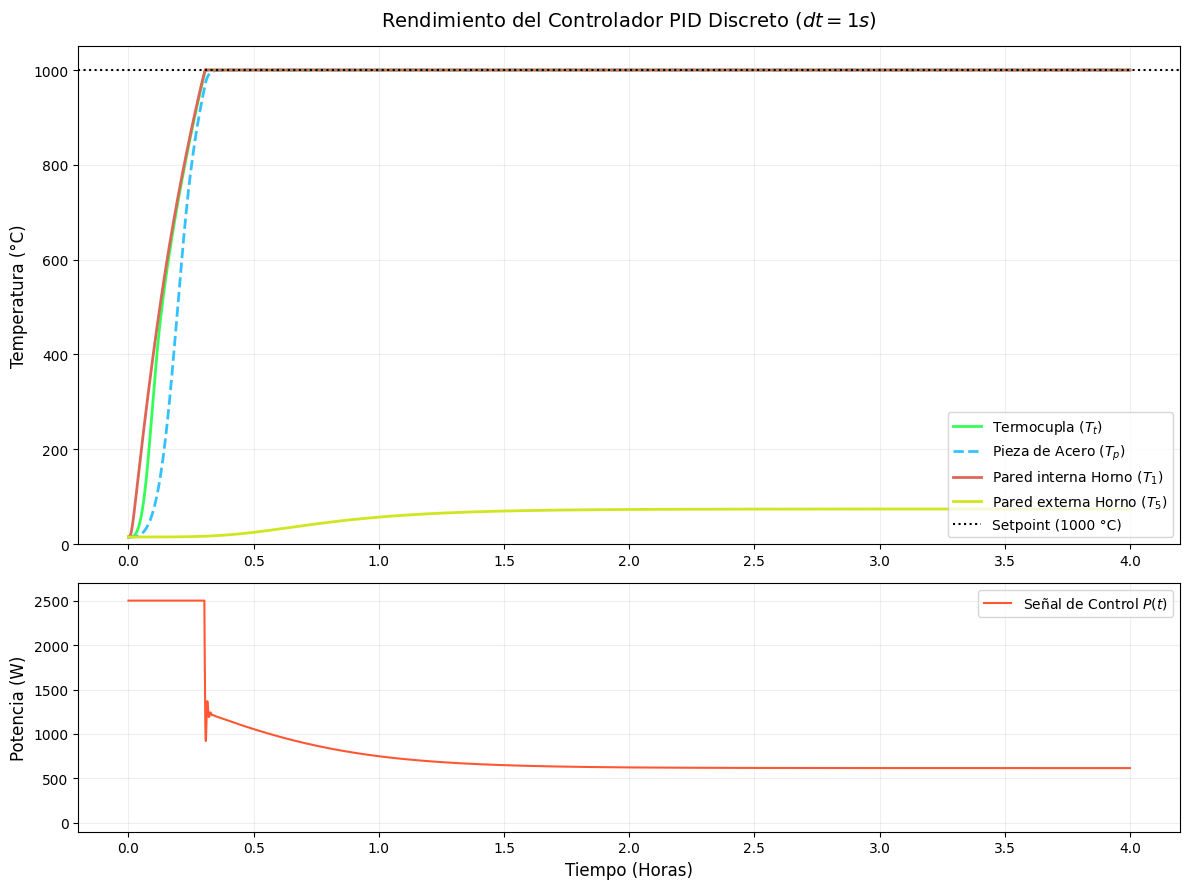

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

# ==========================================
# 1. Propiedades Dependientes de la Temperatura
# ==========================================
def c_r(T_C): return -0.0002 * (T_C**2) + 0.4804 * T_C + 467.6354
def k_lra(T_C): return -1e-8 * (T_C**2) + 0.0002 * T_C + 0.0990
def k_fc(T_C): return 9e-7 * (T_C**2) + 0.0009 * T_C + 0.3033
def k_lr(T_C): return 2e-7 * (T_C**2) + 0.0001 * T_C + 0.0301

# ==========================================
# 2. Planta Física: Ecuaciones Diferenciales (Continuas)
# ==========================================
def horno_planta_ode(t, y, P_inyectada, T_amb, m_p):
    if m_p != 0.0:
        Tr, Tp, Tt, T1, T2, T3, T4, T5 = y
    else:
        Tr, Tt, T1, T2, T3, T4, T5 = y
    
    # Conversiones y Evaluaciones Térmicas
    Tr_C = Tr - 273.15
    T12_C = ((T1 + T2) / 2.0) - 273.15
    T23_C = ((T2 + T3) / 2.0) - 273.15
    T34_C = ((T3 + T4) / 2.0) - 273.15
    T45_C = ((T4 + T5) / 2.0) - 273.15
    
    cr_val = c_r(Tr_C)
    klra_val_12 = k_lra(T12_C)
    kfc_val_23  = k_fc(T23_C)
    klr_val_34  = k_lr(T34_C)
    klr_val_45  = k_lr(T45_C)
    
    # Ecuaciones Diferenciales
    dTr_dt = (3.44 / cr_val) * P_inyectada - (1.24e-8 / cr_val) * (Tr**4 - T1**4)
    if m_p != 0.0:
        dTp_dt = (7.99e-13 + 6.57e-13 * np.sqrt(1/m_p)) * (T1**4 - Tp**4)
    dTt_dt = 2.0679e-11 * (T1**4 - Tt**4)
    if m_p != 0:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4) - 7.80e-14 * (T1**4 - Tp**4)
    else:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4)
    dT2_dt = 0.0026 * klra_val_12 * (T1 - T2) - 0.0051 * kfc_val_23 * (T2 - T3)
    dT3_dt = 0.0113 * kfc_val_23 * (T2 - T3) - 0.0161 * klr_val_34 * (T3 - T4)
    dT4_dt = 0.0253 * klr_val_34 * (T3 - T4) - 0.0342 * klr_val_45 * (T4 - T5)
    dT5_dt = 0.0595 * klr_val_45 * (T4 - T5) - 0.0202 * (T5 - T_amb) - 1.98e-11 * (T5**4 - T_amb**4)
    
    if m_p != 0.0:
        return [dTr_dt, dTp_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]
    else:
        return [dTr_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]

# ==========================================
# 3. Lógica Discreta: Controlador PID
# ==========================================
class ControladorPID:
    def __init__(self, Kp, Tau_I, Tau_D, dt, out_min=0.0, out_max=2500.0):
        self.Kp = Kp
        self.Tau_I = Tau_I
        self.Tau_D = Tau_D
        self.dt = dt
        self.out_min = out_min
        self.out_max = out_max
        self.error_previo = 0.0
        self.integral = 0.0

    def calcular(self, setpoint, temperatura_actual):
        error = setpoint - temperatura_actual
        P = self.Kp * error
        
        # Anti-Windup en el término integral
        if self.Tau_I > 0:
            incremento_i = self.Kp * (self.dt / self.Tau_I) * error
            self.integral += incremento_i
        else:
            self.integral = 0.0
            
        I = self.integral
        
        D = 0.0
        if self.dt > 0:
            D = self.Kp * self.Tau_D * ((error - self.error_previo) / self.dt)
            
        salida = P + I + D
        
        # Saturación del SSR
        if salida > self.out_max:
            salida = self.out_max
            if self.Tau_I > 0: self.integral -= incremento_i 
        elif salida < self.out_min:
            salida = self.out_min
            if self.Tau_I > 0: self.integral -= incremento_i
            
        self.error_previo = error
        return salida

# ==========================================
# 4. Bucle Principal de Simulación Acoplada
# ==========================================
T_amb_C = 15.0
T_amb = T_amb_C + 273.15
P_max_sistema = 2500.0  
T_setpoint_C = 1000.0
m_p = 0.120

# Parámetros del PID (Ejemplo: Ajusta estos valores según tus cálculos de Ziegler-Nichols)
Kp_calc = 417.6
Tau_I_calc = 19.8 
Tau_D_calc = 4.95  

dt_segundos = 1.0  # El microcontrolador ejecuta el PID cada 1 segundo
tiempo_total_horas = 4.0
pasos_totales = int((tiempo_total_horas * 3600) / dt_segundos)

pid = ControladorPID(Kp=Kp_calc, Tau_I=Tau_I_calc, Tau_D=Tau_D_calc, 
                     dt=dt_segundos, out_min=0.0, out_max=P_max_sistema)

# Vectores para almacenar el historial (para la gráfica)
historial_t = np.zeros(pasos_totales)
historial_Tt = np.zeros(pasos_totales)
if m_p != 0.0:
    historial_Tp = np.zeros(pasos_totales)
historial_T1 = np.zeros(pasos_totales)
historial_T5 = np.zeros(pasos_totales)
historial_P = np.zeros(pasos_totales)

# Estado inicial
if m_p != 0.0:
    y_actual = [T_amb] * 8
else:
    y_actual = [T_amb] * 7

print("Iniciando integración digital-continua. Este proceso puede tardar unos segundos...")
inicio_timer = time.time()

for i in range(pasos_totales):
    t_inicio = i * dt_segundos
    t_fin = t_inicio + dt_segundos
    
    # 1. Lectura del sensor
    if m_p != 0:
        Tt_actual_C = y_actual[2] - 273.15
    else:
        Tt_actual_C = y_actual[1] - 273.15
    
    # 2. El algoritmo digital calcula la potencia
    potencia_pwm = pid.calcular(T_setpoint_C, Tt_actual_C)
    
    # 3. Guardar registros
    historial_t[i] = t_inicio / 3600  # Guardar en horas
    historial_Tt[i] = Tt_actual_C
    if m_p != 0.0:
        historial_Tp[i] = y_actual[1] - 273.15
        historial_T1[i] = y_actual[3] - 273.15
        historial_T5[i] = y_actual[7] - 273.15
    else:
        historial_T1[i] = y_actual[2] - 273.15
        historial_T5[i] = y_actual[6] - 273.15
    historial_P[i] = potencia_pwm
    
    # 4. Simular la física del horno durante ese segundo exacto
    # Se inyecta la potencia_pwm como una constante durante este intervalo
    sol = solve_ivp(
        fun=lambda t, y: horno_planta_ode(t, y, potencia_pwm, T_amb, m_p),
        t_span=(t_inicio, t_fin),
        y0=y_actual,
        method='Radau', # Mantenemos Radau para manejar la rigidez térmica
        rtol=1e-3, atol=1e-6
    )
    
    # Actualizar el estado del horno para el siguiente segundo
    y_actual = sol.y[:, -1]
    
    if i % 3600 == 0 and i > 0:
        print(f"--> {i//3600} horas de operación simuladas...")

print(f"Simulación completada en {time.time() - inicio_timer:.2f} segundos.")

# ==========================================
# 5. Visualización del Comportamiento
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [2, 1]})
plt.rcdefaults()
#plt.style.use('default')

# Gráfica de Respuesta Térmica
ax1.plot(historial_t, historial_Tt, label='Termocupla ($T_t$)', color='#33FF57', linewidth=2)
if m_p != 0.0:
    ax1.plot(historial_t, historial_Tp, label='Pieza de Acero ($T_p$)', color='#33C1FF', linestyle='--', linewidth=2)
ax1.plot(historial_t, historial_T1, label='Pared interna Horno ($T_1$)', color='#DE6657', linewidth=2)
ax1.plot(historial_t, historial_T5, label='Pared externa Horno ($T_5$)', color='#CFE620', linewidth=2)
ax1.axhline(T_setpoint_C, color='black', linestyle=':', linewidth=1.5, label='Setpoint (1000 °C)')
ax1.set_title('Rendimiento del Controlador PID Discreto ($dt=1s$)', fontsize=14, pad=15)
ax1.set_ylabel('Temperatura (°C)', fontsize=12)
ax1.set_ylim(0, 1050)
ax1.grid(True, alpha=0.2)
ax1.legend(loc='lower right')

# Gráfica de Esfuerzo de Control (Acción del SSR)
ax2.plot(historial_t, historial_P, label='Señal de Control $P(t)$', color='#FF5733', linewidth=1.5)
ax2.set_xlabel('Tiempo (Horas)', fontsize=12)
ax2.set_ylabel('Potencia (W)', fontsize=12)
ax2.set_ylim(-100, P_max_sistema + 200)
ax2.grid(True, alpha=0.2)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

El siguiente programa realzia una simulación del comportamiento junto a un controlador PID con una entrada rampa con temperatura final de $1000\text{ °C}$ y una velocidad de elevación de temeperatura de $10\text{ °C/min}$

Iniciando simulación con perfil de Rampa Térmica...
--> 1 horas de operación simuladas...
--> 2 horas de operación simuladas...
--> 3 horas de operación simuladas...
Simulación completada en 16.30 segundos.


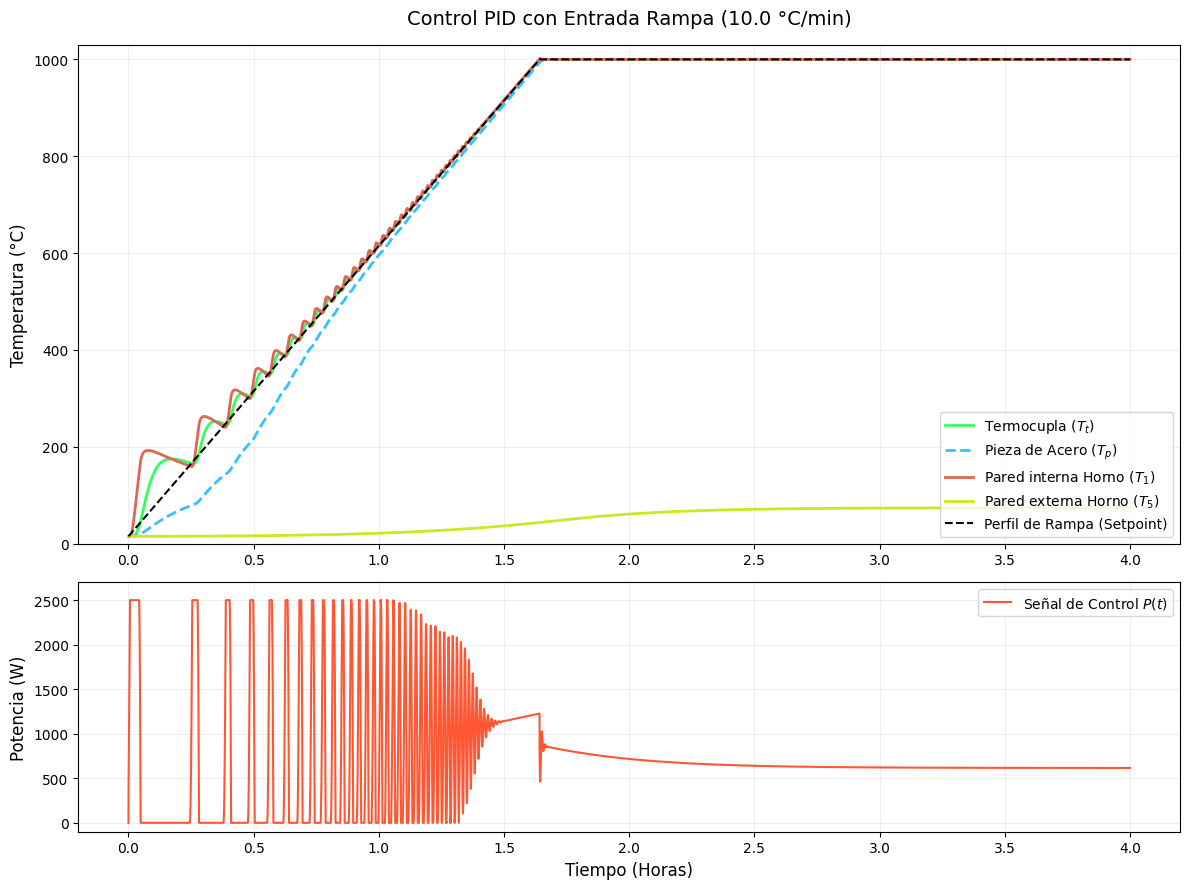

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

# ==========================================
# 1. Propiedades Dependientes de la Temperatura
# ==========================================
def c_r(T_C): return -0.0002 * (T_C**2) + 0.4804 * T_C + 467.6354
def k_lra(T_C): return -1e-8 * (T_C**2) + 0.0002 * T_C + 0.0990
def k_fc(T_C): return 9e-7 * (T_C**2) + 0.0009 * T_C + 0.3033
def k_lr(T_C): return 2e-7 * (T_C**2) + 0.0001 * T_C + 0.0301

# ==========================================
# 2. Planta Física: Ecuaciones Diferenciales
# ==========================================
def horno_planta_ode(t, y, P_inyectada, T_amb, m_p):
    if m_p != 0.0:
        Tr, Tp, Tt, T1, T2, T3, T4, T5 = y
    else:
        Tr, Tt, T1, T2, T3, T4, T5 = y
    
    Tr_C = Tr - 273.15
    T12_C = ((T1 + T2) / 2.0) - 273.15
    T23_C = ((T2 + T3) / 2.0) - 273.15
    T34_C = ((T3 + T4) / 2.0) - 273.15
    T45_C = ((T4 + T5) / 2.0) - 273.15
    
    cr_val = c_r(Tr_C)
    klra_val_12 = k_lra(T12_C)
    kfc_val_23  = k_fc(T23_C)
    klr_val_34  = k_lr(T34_C)
    klr_val_45  = k_lr(T45_C)
    
    dTr_dt = (3.44 / cr_val) * P_inyectada - (1.24e-8 / cr_val) * (Tr**4 - T1**4)
    if m_p != 0.0:
        dTp_dt = (7.99e-13 + 6.57e-13 * np.sqrt(1/m_p)) * (T1**4 - Tp**4)
    dTt_dt = 2.0679e-11 * (T1**4 - Tt**4)
    if m_p != 0:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4) - 7.80e-14 * (T1**4 - Tp**4)
    else:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4)
    dT2_dt = 0.0026 * klra_val_12 * (T1 - T2) - 0.0051 * kfc_val_23 * (T2 - T3)
    dT3_dt = 0.0113 * kfc_val_23 * (T2 - T3) - 0.0161 * klr_val_34 * (T3 - T4)
    dT4_dt = 0.0253 * klr_val_34 * (T3 - T4) - 0.0342 * klr_val_45 * (T4 - T5)
    dT5_dt = 0.0595 * klr_val_45 * (T4 - T5) - 0.0202 * (T5 - T_amb) - 1.98e-11 * (T5**4 - T_amb**4)
    
    if m_p != 0.0:
        return [dTr_dt, dTp_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]
    else:
        return [dTr_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]

# ==========================================
# 3. Lógica Discreta: Controlador PID
# ==========================================
class ControladorPID:
    def __init__(self, Kp, Tau_I, Tau_D, dt, out_min=0.0, out_max=2500.0):
        self.Kp = Kp
        self.Tau_I = Tau_I
        self.Tau_D = Tau_D
        self.dt = dt
        self.out_min = out_min
        self.out_max = out_max
        self.error_previo = 0.0
        self.integral = 0.0

    def calcular(self, setpoint, temperatura_actual):
        error = setpoint - temperatura_actual
        P = self.Kp * error
        
        # Anti-Windup en el término integral
        if self.Tau_I > 0:
            incremento_i = self.Kp * (self.dt / self.Tau_I) * error
            self.integral += incremento_i
        else:
            self.integral = 0.0
            
        I = self.integral
        
        D = 0.0
        if self.dt > 0:
            D = self.Kp * self.Tau_D * ((error - self.error_previo) / self.dt)
            
        salida = P + I + D
        
        # Saturación
        if salida > self.out_max:
            salida = self.out_max
            if self.Tau_I > 0: self.integral -= incremento_i 
        elif salida < self.out_min:
            salida = self.out_min
            if self.Tau_I > 0: self.integral -= incremento_i
            
        self.error_previo = error
        return salida

# ==========================================
# 4. Bucle Principal de Simulación Acoplada (CON RAMPA)
# ==========================================
T_amb_C = 15.0
T_amb = T_amb_C + 273.15
P_max_sistema = 2500.0
m_p = 0.120

# --- PARÁMETROS DEL PERFIL DE TEMPERATURA ---
T_objetivo_C = 1000.0
tasa_calentamiento_min = 10.0  # Velocidad de la rampa: 10 °C por minuto
tasa_calentamiento_seg = tasa_calentamiento_min / 60.0 # Convertido para el dt

# Parámetros del PID
Kp_calc = 417.6
Tau_I_calc = 19.8 
Tau_D_calc = 4.95   

dt_segundos = 1.0  
tiempo_total_horas = 4.0
pasos_totales = int((tiempo_total_horas * 3600) / dt_segundos)

pid = ControladorPID(Kp=Kp_calc, Tau_I=Tau_I_calc, Tau_D=Tau_D_calc, 
                     dt=dt_segundos, out_min=0.0, out_max=P_max_sistema)

# Vectores para almacenar el historial
historial_t = np.zeros(pasos_totales)
historial_Tt = np.zeros(pasos_totales)
if m_p != 0.0:
    historial_Tp = np.zeros(pasos_totales)
historial_T1 = np.zeros(pasos_totales)
historial_T5 = np.zeros(pasos_totales)
historial_P = np.zeros(pasos_totales)
historial_SP = np.zeros(pasos_totales) # <- Nuevo vector para guardar la rampa

if m_p != 0.0:
    y_actual = [T_amb] * 8
else:
    y_actual = [T_amb] * 7

print("Iniciando simulación con perfil de Rampa Térmica...")
inicio_timer = time.time()

for i in range(pasos_totales):
    t_inicio = i * dt_segundos
    t_fin = t_inicio + dt_segundos
    
    # 1. Generador de Rampa (Cálculo del Setpoint Actual)
    # Aumenta gradualmente desde la temperatura ambiente
    setpoint_dinamico = T_amb_C + (tasa_calentamiento_seg * t_inicio)
    
    # Cuando alcanza el objetivo, se mantiene constante (Fase Soak)
    if setpoint_dinamico > T_objetivo_C:
        setpoint_dinamico = T_objetivo_C
    
    # 2. Lectura del sensor
    if m_p != 0:
        Tt_actual_C = y_actual[2] - 273.15
    else:
        Tt_actual_C = y_actual[1] - 273.15
    
    # 3. El PID persigue el setpoint dinámico, no el objetivo final
    potencia_pwm = pid.calcular(setpoint_dinamico, Tt_actual_C)
    
    # Guardar registros
    historial_t[i] = t_inicio / 3600 
    historial_Tt[i] = Tt_actual_C
    if m_p != 0.0:
        historial_Tp[i] = y_actual[1] - 273.15
        historial_T1[i] = y_actual[3] - 273.15
        historial_T5[i] = y_actual[7] - 273.15
    else:
        historial_T1[i] = y_actual[2] - 273.15
        historial_T5[i] = y_actual[6] - 273.15
    historial_P[i] = potencia_pwm
    historial_SP[i] = setpoint_dinamico # Guardamos la rampa para la gráfica
    
    # 4. Simular la física
    sol = solve_ivp(
        fun=lambda t, y: horno_planta_ode(t, y, potencia_pwm, T_amb, m_p),
        t_span=(t_inicio, t_fin),
        y0=y_actual,
        method='Radau', 
        rtol=1e-3, atol=1e-6
    )
    
    y_actual = sol.y[:, -1]
    
    if i % 3600 == 0 and i > 0:
        print(f"--> {i//3600} horas de operación simuladas...")

print(f"Simulación completada en {time.time() - inicio_timer:.2f} segundos.")

# ==========================================
# 5. Visualización del Comportamiento (Actualizado)
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [2, 1]})
plt.style.use('default')

# Gráfica de Respuesta Térmica
ax1.plot(historial_t, historial_Tt, label='Termocupla ($T_t$)', color='#33FF57', linewidth=2)
if m_p != 0.0:
    ax1.plot(historial_t, historial_Tp, label='Pieza de Acero ($T_p$)', color='#33C1FF', linestyle='--', linewidth=2)
ax1.plot(historial_t, historial_T1, label='Pared interna Horno ($T_1$)', color='#DE6657', linewidth=2)
ax1.plot(historial_t, historial_T5, label='Pared externa Horno ($T_5$)', color='#CFE620', linewidth=2)
# Reemplazamos la línea plana por la curva del setpoint dinámico
ax1.plot(historial_t, historial_SP, label='Perfil de Rampa (Setpoint)', color='black', linestyle='--', linewidth=1.5)

ax1.set_title(f'Control PID con Entrada Rampa ({tasa_calentamiento_min} °C/min)', fontsize=14, pad=15)
ax1.set_ylabel('Temperatura (°C)', fontsize=12)
ax1.set_ylim(0, 1030)
ax1.grid(True, alpha=0.2)
ax1.legend(loc='lower right')

# Gráfica de Esfuerzo de Control
ax2.plot(historial_t, historial_P, label='Señal de Control $P(t)$', color='#FF5733', linewidth=1.5)
ax2.set_xlabel('Tiempo (Horas)', fontsize=12)
ax2.set_ylabel('Potencia (W)', fontsize=12)
ax2.set_ylim(-100, P_max_sistema + 200)
ax2.grid(True, alpha=0.2)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()